In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [3]:
np.random.seed(42)
tf.random.set_seed(42)

# 1000 samples, 4 input features
X = np.random.randn(1000, 4)

# True underlying function (unknown to model)
true_W = np.array([
    [1.5, -2.0, 0.7, 0.3],
    [-0.8, 1.2, -1.5, 2.0],
    [0.5, 0.3, -0.2, 1.0]
])

y = X @ true_W.T + np.random.randn(1000, 3) * 0.5

Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.5038 - mae: 1.6402 - val_loss: 1.5235 - val_mae: 0.9650 - learning_rate: 0.0100
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1205 - mae: 0.8313 - val_loss: 0.5801 - val_mae: 0.6045 - learning_rate: 0.0100
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4751 - mae: 0.5514 - val_loss: 0.3908 - val_mae: 0.4908 - learning_rate: 0.0100
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3532 - mae: 0.4722 - val_loss: 0.3377 - val_mae: 0.4584 - learning_rate: 0.0100
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3197 - mae: 0.4496 - val_loss: 0.3216 - val_mae: 0.4447 - learning_rate: 0.0100
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3060 - mae: 0.4393 - val_loss: 0.3105 - val_mae: 0.4393 - learning_rate: 0.0100
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2983 - mae: 0.4340 - val_loss: 0.3029 - val_mae: 0.4345 - learning_rate: 0.0100
Epoch 8/100
25/25 ━━━━━━━

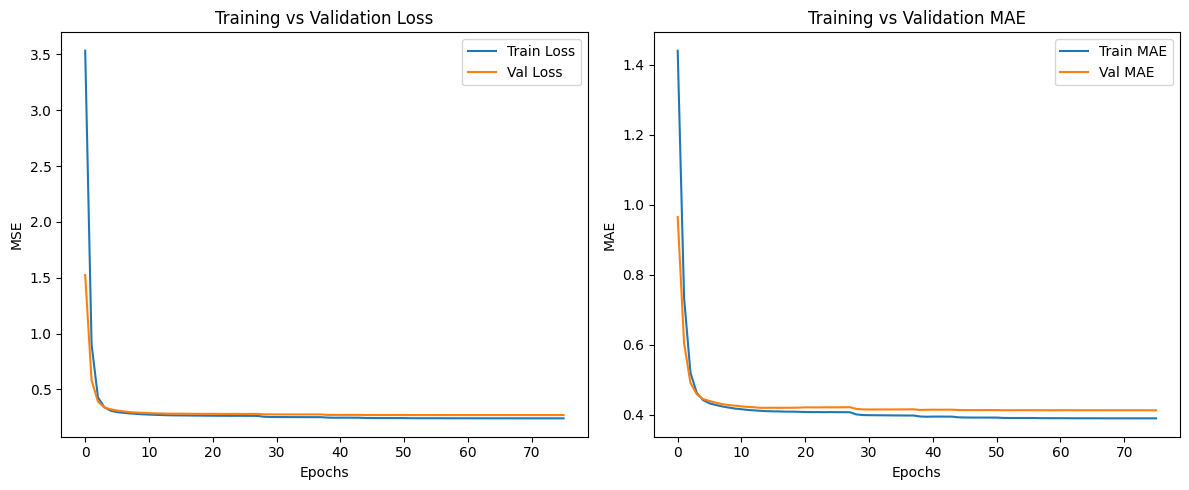

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 731 (2.86 KB)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 488 (1.91 KB)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#input scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


#initializing the nn
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu", input_shape=(4,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(3)
])


#compiling the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

val_loss, val_mae = model.evaluate(X_val, y_val)
print(f"Validation Loss (MSE): {val_loss:.4f}")
print(f"Validation MAE: {val_mae:.4f}")

predictions = model.predict(X_val)
print("Sample predictions:\n", predictions[:5])

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")
plt.legend()

# MAE
plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()

plt.tight_layout()
plt.show()

model.summary()